# EdgeVision PPE Compliance — V1 Full Pipeline

This is a **working end-to-end V1**: person tracking → PPE detection → person-to-PPE association → zone rule engine → temporal validation → violation logging + annotated video output.

**What V1 covers (this notebook):**
- Auto-downloaded public PPE dataset (no manual download needed)
- Training a custom PPE detector (helmet, vest, boots, gloves, goggles + their "missing" counterparts)
- Person detection + tracking (ByteTrack via Ultralytics)
- Person-to-PPE association (bounding-box containment)
- Configurable zone rule engine
- Temporal validation (reduces false alerts, per PRD Stage 5)
- Violation logging to CSV + annotated output video

**What's deferred to V2/V3 (not in this notebook):**
- V2: PostgreSQL database, FastAPI backend, React dashboard (real web app instead of CSV/local video)
- V3: Jetson deployment — ONNX export, TensorRT engine, DeepStream pipeline
- Harness / lanyard / hook / anchor-point detection — the public dataset used here does **not** include these work-at-height-specific items. You'll need to label a small custom dataset for those later (the PRD itself expects this — see 'Hard-negative examples' section). V1 handles helmet/vest/boots/gloves/goggles compliance, which is enough for the *General plant* and *Construction* zones.

Run cells top to bottom. Only manual step: drop a video file named `input_video.mp4` in this folder (or set `INPUT_VIDEO = 0` to use a webcam).

## Step 1: Install dependencies
Run once.

In [1]:
# !pip install ultralytics opencv-python matplotlib pandas

import os
import time
import json
from collections import defaultdict, deque

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
import torch

print("Ultralytics + OpenCV ready")
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU (training will be slow — reduce epochs if needed)")

Ultralytics + OpenCV ready
CUDA available: True
Device: NVIDIA GeForce RTX 4050 Laptop GPU


In [30]:
import warnings
warnings.filterwarnings("ignore")

## Step 2: Create folder structure
All folders are created automatically — no manual setup needed.

In [2]:
PROJECT_ROOT = "edgevision_v1"
FOLDERS = [
    f"{PROJECT_ROOT}/datasets",
    f"{PROJECT_ROOT}/runs",
    f"{PROJECT_ROOT}/outputs/videos",
    f"{PROJECT_ROOT}/outputs/logs",
]
for f in FOLDERS:
    os.makedirs(f, exist_ok=True)
print("Folder structure ready:")
for f in FOLDERS:
    print(" -", f)

Folder structure ready:
 - edgevision_v1/datasets
 - edgevision_v1/runs
 - edgevision_v1/outputs/videos
 - edgevision_v1/outputs/logs


edgevision_v1/runs []


## Step 3: PPE Training Dataset

Using the **Ultralytics Construction-PPE** dataset — it auto-downloads the first time you train, no Kaggle account or API key needed. 1,416 images, 11 classes: `helmet, gloves, vest, boots, goggles, no_helmet, no_gloves, no_boots, no_goggle, Person, none`.

**Alternative (optional):** the Kaggle "Construction Site Safety Image Dataset (Roboflow)" has explicit `NO-Hardhat` / `NO-Safety Vest` negative classes and more images (2,801). To use it instead:
1. `pip install kaggle`
2. Go to kaggle.com → Account Settings → "Create New API Token" → downloads `kaggle.json`
3. Place it at `~/.kaggle/kaggle.json` (Linux/Mac) or `C:\Users\<you>\.kaggle\kaggle.json` (Windows)
4. Run: `kaggle datasets download -d snehilsanyal/construction-site-safety-image-dataset-roboflow -p edgevision_v1/datasets --unzip`

This notebook uses the auto-download option by default — nothing to do here, just run the training cell below.

In [8]:
# PPE_MODEL_PATH = f"{PROJECT_ROOT}/runs/ppe_detect/weights/best.pt"
PPE_MODEL_PATH = f"{PROJECT_ROOT}/runs/ppe_detect-2/weights/best.pt"
if not os.path.exists(PPE_MODEL_PATH):
    ppe_base = YOLO("yolov8n.pt")  # transfer learning from COCO-pretrained weights

    train_results = ppe_base.train(
        data="construction-ppe.yaml",   # auto-downloads on first use
        epochs=50,                       
        imgsz=640,
        batch=16,
        patience=15,
        device=0 if torch.cuda.is_available() else "cpu",
        project=f"{PROJECT_ROOT}/runs",
        name="ppe_detect",
    )
    print("Training complete. Best weights saved to:", PPE_MODEL_PATH)
else:
    print("Found existing trained weights, skipping training:", PPE_MODEL_PATH)

Ultralytics 8.4.113  Python-3.11.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=construction-ppe.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_detect-3, nbs

W:\3 projects\Building\Tfrenzy\ppe-env\Lib\site-packages\ultralytics\utils\metrics.py:883: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
W:\3 projects\Building\Tfrenzy\ppe-env\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50      2.55G      2.005      4.518      1.894         63        640: 100% ━━━━━━━━━━━━ 71/71 3.2it/s 21.9s0.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.9it/s 2.7s0.8s
                   all        143          0          0          0          0          0
WARNING no labels found in detect set, cannot compute metrics without labels


W:\3 projects\Building\Tfrenzy\ppe-env\Lib\site-packages\ultralytics\utils\metrics.py:883: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
W:\3 projects\Building\Tfrenzy\ppe-env\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      2.55G      1.977      4.084        1.9         50        640: 100% ━━━━━━━━━━━━ 71/71 3.6it/s 19.6s0.3ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.5it/s 2.0s0.6s
                   all        143          0          0          0          0          0
WARNING no labels found in detect set, cannot compute metrics without labels


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      50/50      2.55G      1.259      1.528      1.406          0        640: 100% ━━━━━━━━━━━━ 71/71 4.0it/s 17.8s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 4.9it/s 1.0s0.3s
                   all        143          0          0          0          0          0
WARNING no labels found in detect set, cannot compute metrics without labels


W:\3 projects\Building\Tfrenzy\ppe-env\Lib\site-packages\ultralytics\utils\metrics.py:883: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
W:\3 projects\Building\Tfrenzy\ppe-env\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



50 epochs completed in 0.309 hours.
Optimizer stripped from W:\3 projects\Building\Tfrenzy\notebook\runs\detect\edgevision_v1\runs\ppe_detect-3\weights\last.pt, 6.3MB
Optimizer stripped from W:\3 projects\Building\Tfrenzy\notebook\runs\detect\edgevision_v1\runs\ppe_detect-3\weights\best.pt, 6.3MB

Validating W:\3 projects\Building\Tfrenzy\notebook\runs\detect\edgevision_v1\runs\ppe_detect-3\weights\best.pt...
Ultralytics 8.4.113  Python-3.11.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 73 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.7it/s 2.9s0.8s


W:\3 projects\Building\Tfrenzy\ppe-env\Lib\site-packages\ultralytics\utils\metrics.py:698: RuntimeWarning: Mean of empty slice
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
W:\3 projects\Building\Tfrenzy\ppe-env\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
W:\3 projects\Building\Tfrenzy\ppe-env\Lib\site-packages\ultralytics\utils\metrics.py:745: RuntimeWarning: Mean of empty slice
  y = smooth(py.mean(0), 0.1)
W:\3 projects\Building\Tfrenzy\ppe-env\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
W:\3 projects\Building\Tfrenzy\ppe-env\Lib\site-packages\ultralytics\utils\metrics.py:745: RuntimeWarning: Mean of empty slice
  y = smooth(py.mean(0), 0.1)
W:\3 projects\Building\Tfrenzy\ppe-env\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid 

                   all        143          0          0          0          0          0
WARNING no labels found in detect set, cannot compute metrics without labels
Speed: 0.5ms preprocess, 5.3ms inference, 0.0ms loss, 7.7ms postprocess per image
Results saved to W:\3 projects\Building\Tfrenzy\notebook\runs\detect\edgevision_v1\runs\ppe_detect-3
Training complete. Best weights saved to: edgevision_v1/runs/ppe_detect-2/weights/best.pt


In [14]:
import glob, os

for p in glob.glob("**/best.pt", recursive=True):
    print(p, "-", os.path.getmtime(p))

runs\detect\edgevision_v1\runs\ppe_detect-2\weights\best.pt - 1785478412.755575
runs\detect\edgevision_v1\runs\ppe_detect-3\weights\best.pt - 1785480070.5985162
runs\detect\edgevision_v1\runs\ppe_detect-4\weights\best.pt - 1785480698.9483857


### Evaluate the PPE model (Precision, Recall, mAP50, mAP50-95 — PRD Stage 5 metrics)

In [15]:
PPE_MODEL_PATH = "runs/detect/edgevision_v1/runs/ppe_detect-4/weights/best.pt"

ppe_model = YOLO(PPE_MODEL_PATH)
metrics = ppe_model.val(data="construction-ppe.yaml", split="val")

print("mAP50:      ", metrics.box.map50)
print("mAP50-95:   ", metrics.box.map)
print("Per-class P:", dict(zip(ppe_model.names.values(), metrics.box.p)))
print("Per-class R:", dict(zip(ppe_model.names.values(), metrics.box.r)))

Ultralytics 8.4.113  Python-3.11.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 73 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 502.9390.7 MB/s, size: 194.0 KB)
val: Scanning W:\3 projects\Building\Tfrenzy\notebook\datasets\construction-ppe\labels\val.cache... 0 images, 143 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 143/143  0.0s
WARNING Labels are missing or empty in W:\3 projects\Building\Tfrenzy\notebook\datasets\construction-ppe\labels\val.cache, training may not work correctly. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.3s/it 11.4s0.4s


W:\3 projects\Building\Tfrenzy\ppe-env\Lib\site-packages\ultralytics\utils\metrics.py:698: RuntimeWarning: Mean of empty slice
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
W:\3 projects\Building\Tfrenzy\ppe-env\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
W:\3 projects\Building\Tfrenzy\ppe-env\Lib\site-packages\ultralytics\utils\metrics.py:745: RuntimeWarning: Mean of empty slice
  y = smooth(py.mean(0), 0.1)
W:\3 projects\Building\Tfrenzy\ppe-env\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
W:\3 projects\Building\Tfrenzy\ppe-env\Lib\site-packages\ultralytics\utils\metrics.py:745: RuntimeWarning: Mean of empty slice
  y = smooth(py.mean(0), 0.1)
W:\3 projects\Building\Tfrenzy\ppe-env\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid 

                   all        143          0          0          0          0          0
WARNING no labels found in detect set, cannot compute metrics without labels
Speed: 9.5ms preprocess, 9.8ms inference, 0.0ms loss, 4.1ms postprocess per image
Results saved to W:\3 projects\Building\Tfrenzy\notebook\runs\detect\val
mAP50:       0.0
mAP50-95:    0.0
Per-class P: {}
Per-class R: {}


## Step 4: Person detector + tracker
Uses a standard COCO-pretrained model (already knows "person" — class 0) with Ultralytics' built-in ByteTrack for stable tracking IDs across frames (PRD Stage 1).

In [16]:
person_model = YOLO("yolov8n.pt")  
PERSON_CLASS_ID = 0

## Step 5: Person-to-PPE association (PRD Stage 3)
Bounding-box containment: a PPE detection belongs to a person if its center point falls inside that person's box (with a small margin). If more than one person qualifies, pick the closest by center distance.

In [17]:
def box_center(box):
    x1, y1, x2, y2 = box
    return ((x1 + x2) / 2, (y1 + y2) / 2)

def associate_ppe_to_persons(person_boxes, person_ids, ppe_boxes, ppe_classes, margin=15):
    """Returns dict: {person_track_id: [ppe_class_name, ...]}"""
    assignments = defaultdict(list)

    for p_box, p_cls in zip(ppe_boxes, ppe_classes):
        p_cx, p_cy = box_center(p_box)
        best_id, best_dist = None, float("inf")

        for person_box, track_id in zip(person_boxes, person_ids):
            x1, y1, x2, y2 = person_box
            if (x1 - margin) <= p_cx <= (x2 + margin) and (y1 - margin) <= p_cy <= (y2 + margin):
                person_cx, person_cy = box_center(person_box)
                dist = (p_cx - person_cx) ** 2 + (p_cy - person_cy) ** 2
                if dist < best_dist:
                    best_dist, best_id = dist, track_id

        if best_id is not None:
            assignments[best_id].append(p_cls)

    return assignments

## Step 6: Zone rule engine (PRD Stage 4)
Simple config dict for now — V2 will move this into the `zone_ppe_rules` database table with a Zone Configuration dashboard page. For V1, one zone applies to the whole frame.

In [18]:
ZONE_RULES = {
    "general_plant":  {"required": ["helmet", "vest"]},
    "construction":   {"required": ["helmet", "vest", "boots"]},
    # "work_at_height" and "restricted_machinery" need harness/hook/authorisation
    # detection which isn't in this V1 dataset — add in V2 once you have custom labels.
}

CURRENT_ZONE = "construction"   # change to "general_plant" to test the other rule set

def check_compliance(detected_ppe_classes, zone):
    """detected_ppe_classes: list like ['helmet','vest'] or ['no_helmet','vest']
    Returns dict: {item: 'yes'/'no'/'unknown'}"""
    required = ZONE_RULES[zone]["required"]
    status = {}
    for item in required:
        if item in detected_ppe_classes:
            status[item] = "yes"
        elif f"no_{item}" in detected_ppe_classes:
            status[item] = "no"
        else:
            status[item] = "unknown"   # not detected either way this frame
    return status

## Step 7: Temporal validation (PRD Stage 5)
Alert only if a violation appears in **8 of the last 10 frames**, confidence is high enough, and the worker has been in view for **more than 2 seconds** — avoids false alerts from blur/occlusion/single bad frames.

In [19]:
class TemporalValidator:
    def __init__(self, window_size=10, violation_threshold=8, min_seconds_in_zone=2.0, fps=25):
        self.window_size = window_size
        self.violation_threshold = violation_threshold
        self.min_frames_in_zone = int(min_seconds_in_zone * fps)
        self.history = defaultdict(lambda: deque(maxlen=window_size))   l
        self.frames_seen = defaultdict(int)                             

    def update(self, worker_id, compliance_status):
        """compliance_status: {'helmet': 'yes'/'no'/'unknown', ...}
        Returns list of confirmed violations: ['helmet', ...]"""
        self.frames_seen[worker_id] += 1
        confirmed = []

        for item, status in compliance_status.items():
            key = (worker_id, item)
            self.history[key].append(status == "no")

            if (sum(self.history[key]) >= self.violation_threshold
                    and self.frames_seen[worker_id] >= self.min_frames_in_zone):
                confirmed.append(item)

        return confirmed

## Step 8: Full pipeline — run on video
Reads `input_video.mp4` frame by frame, runs both models, associates PPE to workers, applies rules + temporal validation, writes an annotated output video, and logs confirmed violations to CSV.

In [34]:
INPUT_VIDEO = "../docs/test1.mp4"   # put your video here, or set to 0 for webcam
OUTPUT_VIDEO = f"{PROJECT_ROOT}/outputs/videos/annotated_output.mp4"
OUTPUT_LOG = f"{PROJECT_ROOT}/outputs/logs/violations.csv"
CONF_THRESHOLD = 0.25
cap = cv2.VideoCapture(INPUT_VIDEO)
if not cap.isOpened():
    print(f"Could not open {INPUT_VIDEO} — place a video in this folder or set INPUT_VIDEO = 0 for webcam")
else:
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (width, height))

    validator = TemporalValidator(window_size=10, violation_threshold=8, min_seconds_in_zone=2.0, fps=fps)
    violation_log = []
    already_alerted = set()   # (worker_id, item) — avoid repeated alerts for same continuing violation

    frame_idx = 0
    start_time = time.time()

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_idx += 1

        # --- Stage 1: person detection + tracking ---
        person_results = person_model.track(frame, persist=True, classes=[PERSON_CLASS_ID],
                                              conf=CONF_THRESHOLD, verbose=False)[0]
        person_boxes, person_ids = [], []
        if person_results.boxes.id is not None:
            person_boxes = person_results.boxes.xyxy.cpu().numpy().tolist()
            person_ids = person_results.boxes.id.cpu().numpy().astype(int).tolist()

        # --- Stage 2: PPE detection ---
        ppe_results = ppe_model(frame, conf=CONF_THRESHOLD, verbose=False)[0]
        ppe_boxes = ppe_results.boxes.xyxy.cpu().numpy().tolist()
        ppe_classes = [ppe_model.names[int(c)] for c in ppe_results.boxes.cls.cpu().numpy()]

        # --- Stage 3: association ---
        assignments = associate_ppe_to_persons(person_boxes, person_ids, ppe_boxes, ppe_classes)

        # --- Stage 4 + 5: rules + temporal validation ---
        for person_box, worker_id in zip(person_boxes, person_ids):
            detected_items = assignments.get(worker_id, [])
            compliance = check_compliance(detected_items, CURRENT_ZONE)
            confirmed_violations = validator.update(worker_id, compliance)

            x1, y1, x2, y2 = map(int, person_box)
            color = (0, 0, 255) if confirmed_violations else (0, 200, 0)
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            label = f"Worker-{worker_id}"
            if confirmed_violations:
                label += f" MISSING: {','.join(confirmed_violations)}"
            cv2.putText(frame, label, (x1, y1 - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

            for item in confirmed_violations:
                alert_key = (worker_id, item)
                if alert_key not in already_alerted:
                    already_alerted.add(alert_key)
                    violation_log.append({
                        "frame": frame_idx,
                        "timestamp_sec": round(frame_idx / fps, 2),
                        "worker_id": worker_id,
                        "zone": CURRENT_ZONE,
                        "violation_type": item,
                        "missing_ppe": item,
                    })
            # clear alert flag if worker becomes compliant again, so a *new* violation later re-alerts
            for item in compliance:
                if compliance[item] == "yes":
                    already_alerted.discard((worker_id, item))

        writer.write(frame)

    cap.release()
    writer.release()

    elapsed = time.time() - start_time
    print(f"Processed {frame_idx} frames in {elapsed:.1f}s -> {frame_idx/elapsed:.1f} FPS")
    print(f"Annotated video saved to: {OUTPUT_VIDEO}")

    pd.DataFrame(violation_log).to_csv(OUTPUT_LOG, index=False)
    print(f"{len(violation_log)} confirmed violations logged to: {OUTPUT_LOG}")

WARNING GMC failed, falling back to identity: OpenCV(5.0.0) D:\a\opencv-python\opencv-python\opencv\modules\video\src\lkpyramid.cpp:1185: error: (-215:Assertion failed) prevPyr[level * lvlStep1].size() == nextPyr[level * lvlStep2].size() in function 'cv::`anonymous-namespace'::SparsePyrLKOpticalFlowImpl::calc'

WARNING GMC failed, falling back to identity: OpenCV(5.0.0) D:\a\opencv-python\opencv-python\opencv\modules\video\src\lkpyramid.cpp:1185: error: (-215:Assertion failed) prevPyr[level * lvlStep1].size() == nextPyr[level * lvlStep2].size() in function 'cv::`anonymous-namespace'::SparsePyrLKOpticalFlowImpl::calc'

WARNING GMC failed, falling back to identity: OpenCV(5.0.0) D:\a\opencv-python\opencv-python\opencv\modules\video\src\lkpyramid.cpp:1185: error: (-215:Assertion failed) prevPyr[level * lvlStep1].size() == nextPyr[level * lvlStep2].size() in function 'cv::`anonymous-namespace'::SparsePyrLKOpticalFlowImpl::calc'

WARNING GMC failed, falling back to identity: OpenCV(5.0.0) D

### Preview logged violations


In [35]:
try:
    df = pd.read_csv(OUTPUT_LOG)
    display(df)
except (FileNotFoundError, pd.errors.EmptyDataError):
    print("No violations logged (file is empty or missing).")

No violations logged (file is empty or missing).


In [37]:
cap = cv2.VideoCapture(INPUT_VIDEO)
ret, frame = cap.read()
cap.release()

# Use person_model (COCO model knows 'person')
results = person_model(frame, conf=0.25)[0]

if len(results.boxes) == 0:
    print("Nothing detected at all on this frame.")
else:
    for box in results.boxes:
        print(f"Detected: {person_model.names[int(box.cls)]} | Conf: {float(box.conf):.2f}")

WARNING GMC failed, falling back to identity: OpenCV(5.0.0) D:\a\opencv-python\opencv-python\opencv\modules\video\src\lkpyramid.cpp:1185: error: (-215:Assertion failed) prevPyr[level * lvlStep1].size() == nextPyr[level * lvlStep2].size() in function 'cv::`anonymous-namespace'::SparsePyrLKOpticalFlowImpl::calc'

Detected: person | Conf: 0.91


---
## V1 done. Next steps (V2 / V3)

**V2 — make it a real web app:**
- Replace `violations.csv` with the PostgreSQL tables from the PRD (`detection_events`, `violation_events`, `worker_tracks`, etc.)
- Wrap this pipeline in a FastAPI service; push events to the DB instead of a CSV
- Build the React dashboard pages (Live Monitoring, Active Violations, Reports, Zone Configuration)
- Replace the hardcoded `CURRENT_ZONE` with real zone polygons + a Zone Configuration page

**V3 — Jetson deployment:**
- Export `ppe_model` to ONNX, then build a TensorRT FP16 engine on the actual Jetson device
- Move this loop into a DeepStream/GStreamer pipeline for RTSP camera input
- Benchmark FPS / latency / power draw against the PRD targets (12 FPS min, 20+ preferred)

**Known gap to close before final submission:**
- Harness, lanyard, hook, anchor-point detection — label a small custom dataset (a few hundred images is enough to start) since no public dataset covers these well.

In [4]:
import glob
import os

# Your actual Windows directory path
dataset_path = r"W:\3 projects\Building\Tfrenzy\docs\dataset"

# Verify path
if not os.path.exists(dataset_path):
  raise FileNotFoundError(f"Directory not found: {dataset_path}")

print(f"Scanning directory: {dataset_path}\n")

# 1. Look for .yaml config files
yaml_files = glob.glob(f"{dataset_path}/**/*.yaml", recursive=True)
if yaml_files:
  for f in yaml_files:
    print("Found config file:", f)
    print("=" * 40)
    with open(f, "r") as fh:
      print(fh.read())
    print("=" * 40)
else:
  print("No .yaml configuration files found.")

# 2. Find label files (.txt) inside the labels directory
label_files = glob.glob(f"{dataset_path}/**/*.txt", recursive=True)
annotation_files = [
    f for f in label_files if not f.endswith(("classes.txt", "README.txt"))
]

print(f"\nFound {len(annotation_files)} label files.")

# 3. Read unique class indices
classes_seen = set()

for lf in annotation_files[:200]:  # Inspect first 200 label files
  with open(lf, "r") as fh:
    for line in fh:
      parts = line.split()
      if parts:
        try:
          classes_seen.add(int(parts[0]))
        except ValueError:
          continue

print(
    "Unique class indices detected in label sample:", sorted(list(classes_seen))
)

Scanning directory: W:\3 projects\Building\Tfrenzy\docs\dataset

No .yaml configuration files found.

Found 22141 label files.
Unique class indices detected in label sample: [0, 1, 2]


--- STEP 1: Searching for metadata / class names ---

Found metadata file: W:\3 projects\Building\Tfrenzy\docs\dataset\labels\classes.txt
helmet
vest
head
person

--- STEP 2: Drawing bounding boxes on sample images ---


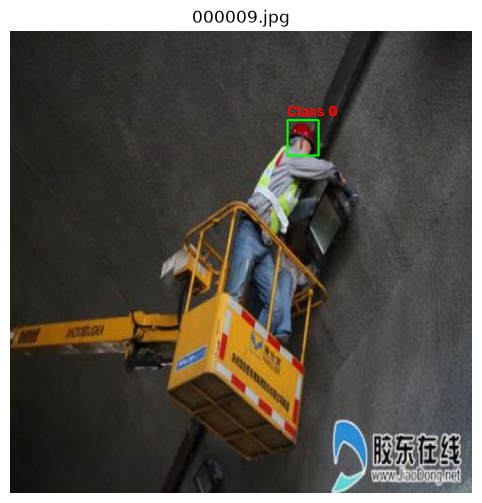

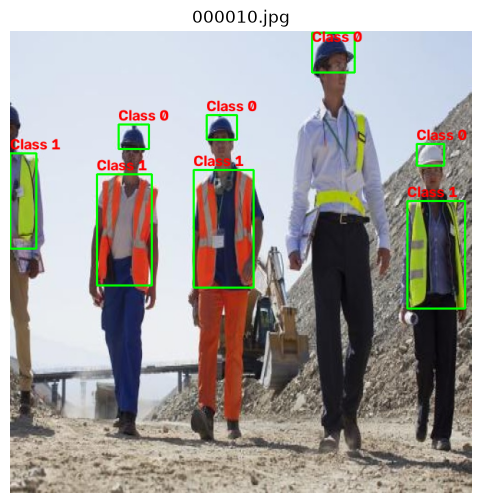

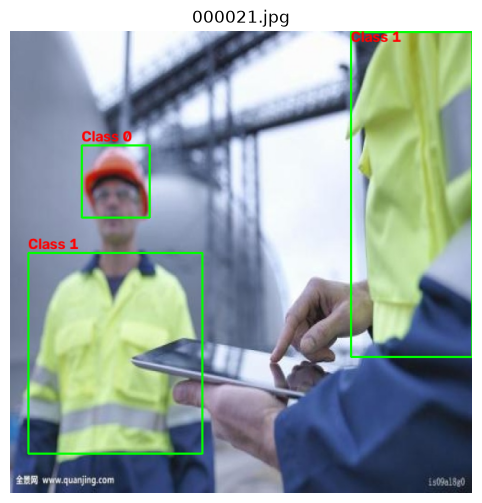

In [5]:
import glob
import os
import cv2
import matplotlib.pyplot as plt

# Your exact dataset path
path = r"W:\3 projects\Building\Tfrenzy\docs\dataset"

# ---------------------------------------------------------
# STEP 1: Search for metadata or class definitions
# ---------------------------------------------------------
print("--- STEP 1: Searching for metadata / class names ---")
metadata_patterns = [
    "**/classes.txt",
    "**/obj.names",
    "**/notes.json",
    "**/*.names",
    "**/README*",
]

found_any = False
for pattern in metadata_patterns:
  found = glob.glob(f"{path}/{pattern}", recursive=True)
  for f in found:
    found_any = True
    print(f"\nFound metadata file: {f}")
    print("=" * 40)
    try:
      with open(f, "r", encoding="utf-8") as file:
        print(file.read())
    except Exception as e:
      print(f"Could not read file: {e}")
    print("=" * 40)

if not found_any:
  print("No class definition files found in metadata search.\n")


# ---------------------------------------------------------
# STEP 2: Draw bounding boxes on sample images to verify classes
# ---------------------------------------------------------
print("--- STEP 2: Drawing bounding boxes on sample images ---")

# Look for image files inside your images folder (handles JPG and PNG)
img_files = (
    glob.glob(f"{path}/images/**/*.jpg", recursive=True)
    + glob.glob(f"{path}/images/**/*.jpeg", recursive=True)
    + glob.glob(f"{path}/images/**/*.png", recursive=True)
)[:3]  # Takes the first 3 images found

if not img_files:
  print(f"No image files found in '{path}/images'. Check your folder structure.")
else:
  for img_path in img_files:
    # Construct corresponding label path (.txt)
    # Replaces 'images' in directory with 'labels' and changes extension
    label_path = (
        img_path.replace("images", "labels")
        .rsplit(".", 1)[0]
        + ".txt"
    )

    if not os.path.exists(label_path):
      print(f"Label missing for image: {img_path}")
      continue

    img = cv2.imread(img_path)
    if img is None:
      print(f"Failed to read image: {img_path}")
      continue

    h, w = img.shape[:2]

    # Read YOLO annotations
    with open(label_path, "r") as f:
      for line in f:
        parts = line.split()
        if len(parts) >= 5:
          cls, xc, yc, bw, bh = map(float, parts[:5])

          # Convert normalized YOLO coordinates to pixel coordinates
          x1 = int((xc - bw / 2) * w)
          y1 = int((yc - bh / 2) * h)
          x2 = int((xc + bw / 2) * w)
          y2 = int((yc + bh / 2) * h)

          # Draw green rectangle for bounding box
          cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

          # Draw red text for class ID label
          cv2.putText(
              img,
              f"Class {int(cls)}",
              (x1, max(y1 - 5, 15)),
              cv2.FONT_HERSHEY_SIMPLEX,
              0.7,
              (0, 0, 255),
              2,
          )

    # Plot image using matplotlib
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(os.path.basename(img_path))
    plt.axis("off")
    plt.show()